## <center>Import des modules</center>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import squarify
%matplotlib inline

In [2]:
df = pd.read_csv('exploration.csv')
pd.set_option('display.max_columns', None)

In [3]:
df['Created_at'] = pd.to_datetime(df['Created_at'])
df['Customer since'] = pd.to_datetime(df['Customer since']).dt.to_period('M')

## <center>Mise en oeuvre de la méthode RFM</center>

Source:
https://www.geeksforgeeks.org/rfm-analysis-analysis-using-python/

##### Calcul de la 'Récence' (temps écoulé depuis la dernière visite effectuée par chaque client)

In [4]:
df.head(1)

,Customer_id,Customer since,Item_id,Increment_id,Sales_commission_code,Qty_ordered,Price,Discount_amount,Net_income,Payment_method,Created_at,Year,Month,Category,Bi_status,Status,Regroupement_status,Regroupement_payment_method,Taux_change,Discount_amount_euros,Net_income_euros,Price_euros
0,4,2016-07,211135,100147446,R-FSD-52352,1,360.0,300.0,60.0,cod,2016-07-01,2016,7,Beauty & Grooming,Net,complete,finalisé,cod,0.008686,2.61,0.52,3.13


In [5]:
# Création d'un nouveau DataFrame df_recency qui quantifie le nombre de jours entre le dernier achat et la fin du dataset

df_recency = df.groupby(by='Customer_id', as_index=False)['Created_at'].max()

df_recency.columns = ['Customer_id', 'DateDernierAchat']

recent_date = df_recency['DateDernierAchat'].max()

df_recency['Recency'] = df_recency['DateDernierAchat'].apply(lambda x: (recent_date - x).days)

df_recency.head()

,Customer_id,DateDernierAchat,Recency
0,4,2018-08-27,1
1,11,2017-02-14,560
2,13,2017-01-10,595
3,20,2018-08-25,3
4,32,2018-08-16,12


##### Calcul de la 'Fréquence' (fréquence d'achat du client)

In [6]:
df_frequency = df.groupby(by=['Customer_id'], as_index=False)['Created_at'].count()

df_frequency.columns = ['Customer_id', 'Frequency']

df_frequency.head()

,Customer_id,Frequency
0,4,392
1,11,6
2,13,192
3,20,420
4,32,626


##### Calcul de la 'Valeur Monétaire' (Somme dépensée par chaque client sur la durée du Dataset)

In [7]:
df_monetary = df.groupby(by='Customer_id', as_index=False)['Net_income_euros'].sum()

df_monetary.columns = ['Customer_id', 'Monetary']

df_monetary.head()

,Customer_id,Monetary
0,4,20285.24
1,11,40.03
2,13,5220.82
3,20,36523.91
4,32,40300.07


##### Création d'un Dataset "df_rfm" global

In [8]:
df_rf = df_recency.merge(df_frequency, on='Customer_id')

df_rfm = df_rf.merge(df_monetary, on='Customer_id').drop(columns='DateDernierAchat')

df_rfm.head()

,Customer_id,Recency,Frequency,Monetary
0,4,1,392,20285.24
1,11,560,6,40.03
2,13,595,192,5220.82
3,20,3,420,36523.91
4,32,12,626,40300.07


----------------------------------------------------------------------------------------------------------------------

### <center>1ère approche RFM</center>

Source :https://www.geeksforgeeks.org/rfm-analysis-analysis-using-python/

##### Calcul du score RFM

Le score RFM est calculé en fonction de la récence, de la fréquence et des classements de normalisation de la valeur monétaire. Sur la base de ce score, nous divisons nos clients. Ici, nous les notons sur une échelle de 5. La formule utilisée pour calculer le score rfm est : 0,15 * Score de récence + 0,28 * Score de fréquence + 0,57 * Score monétaire

In [9]:
df_rfm1 = df_rfm.copy()

In [10]:
df_rfm1['R_rank'] = df_rfm1['Recency'].rank(ascending=False)
df_rfm1['F_rank'] = df_rfm1['Frequency'].rank(ascending=True)
df_rfm1['M_rank'] = df_rfm1['Monetary'].rank(ascending=True)
display(df_rfm1.head())

# Normalisation du rang des Customer_ID
df_rfm1['R_rank_norm'] = (df_rfm1['R_rank']/df_rfm1['R_rank'].max())*100
df_rfm1['F_rank_norm'] = (df_rfm1['F_rank']/df_rfm1['F_rank'].max())*100
df_rfm1['M_rank_norm'] = (df_rfm1['F_rank']/df_rfm1['M_rank'].max())*100
 
df_rfm1.drop(columns=['R_rank', 'F_rank', 'M_rank'], inplace=True)
 
df_rfm1.head()

,Customer_id,Recency,Frequency,Monetary,R_rank,F_rank,M_rank
0,4,1,392,20285.24,13766.5,13743.0,13707.0
1,11,560,6,40.03,3210.0,11200.5,5007.0
2,13,595,192,5220.82,2854.0,13715.0,13550.0
3,20,3,420,36523.91,13755.5,13747.0,13750.0
4,32,12,626,40300.07,13564.0,13756.0,13757.0


,Customer_id,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm
0,4,1,392,20285.24,99.952806,99.774938,99.774938
1,11,560,6,40.03,23.306469,81.316248,81.316248
2,13,595,192,5220.82,20.721702,99.571657,99.571657
3,20,3,420,36523.91,99.872940,99.803979,99.803979
4,32,12,626,40300.07,98.482538,99.869319,99.869319


In [11]:
df_rfm1['RFM_Score'] = (0.15 * df_rfm1['R_rank_norm']) + (0.28 * df_rfm1['F_rank_norm']) + (0.57*df_rfm1['M_rank_norm'])
df_rfm1['RFM_Score'] *= 0.05
df_rfm1 = df_rfm1.round(2)
df_rfm1.head(7)


,Customer_id,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score
0,4,1,392,20285.24,99.95,99.77,99.77,4.99
1,11,560,6,40.03,23.31,81.32,81.32,3.63
2,13,595,192,5220.82,20.72,99.57,99.57,4.39
3,20,3,420,36523.91,99.87,99.80,99.80,4.99
4,32,12,626,40300.07,98.48,99.87,99.87,4.98
5,33,40,1336,84331.23,96.09,99.99,99.99,4.97
6,35,631,1863,17351.28,16.87,99.99,99.99,4.38


#### Classement des clients sur la base de leur score RFM

Nous effectuons un classement client sur la base des règles suivantes :
- rfm score > 4.5 : Top Customer

- 4.5 > rfm score > 4 : High Value Customer

- 4 > rfm score > 3 : Medium value customer

- 3 > rfm score > 1.6 : Low-value customer

- rfm score < 1.6 :Lost Customer


In [12]:
df_rfm1["Customer_segment"] = np.where(df_rfm1['RFM_Score'] > 4.5, "Top Customers",
                                      (np.where(
                                        df_rfm1['RFM_Score'] > 4,
                                        "High value Customer",
                                        (np.where(
    df_rfm1['RFM_Score'] > 3,
                             "Medium Value Customer",
                             np.where(df_rfm1['RFM_Score'] > 1.6,
                            'Low Value Customers', 'Lost Customers'))))))
df_rfm1.head()

,Customer_id,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score,Customer_segment
0,4,1,392,20285.24,99.95,99.77,99.77,4.99,Top Customers
1,11,560,6,40.03,23.31,81.32,81.32,3.63,Medium Value Customer
2,13,595,192,5220.82,20.72,99.57,99.57,4.39,High value Customer
3,20,3,420,36523.91,99.87,99.80,99.80,4.99,Top Customers
4,32,12,626,40300.07,98.48,99.87,99.87,4.98,Top Customers


In [13]:
df_analysis_rfm1 = df_rfm1.groupby('Customer_segment').agg({'Customer_segment':'count'})

df_analysis_rfm1.rename({'Customer_segment':'Total_customer_id'}, axis=1, inplace=True)
df_analysis_rfm1['count_share'] = ((df_analysis_rfm1['Total_customer_id'] / df_analysis_rfm1['Total_customer_id'].sum()) * 100).round(2)

df_analysis_rfm1.sort_values(by='Total_customer_id', ascending=False)

,Total_customer_id,count_share
Customer_segment,,
Lost Customers,5199,37.75
Medium Value Customer,3281,23.82
Low Value Customers,3054,22.17
High value Customer,1475,10.71
Top Customers,765,5.55


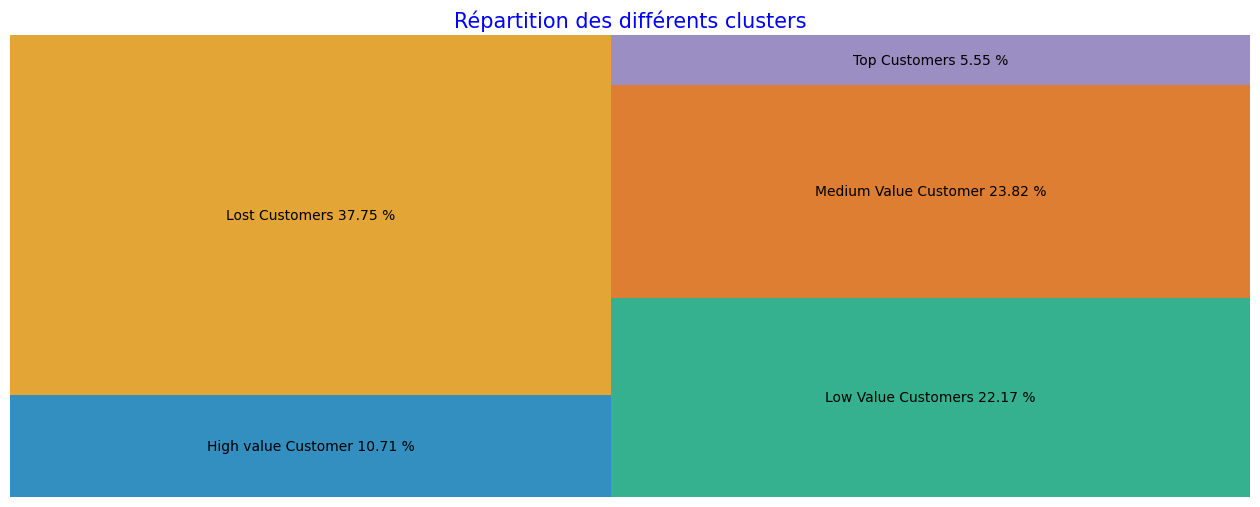

In [14]:
colors =['#0173b2', '#de8f05', '#029e73', '#d55e00', '#8172b3', '#ca9161', '#c44e52', '#949494', '#ece133', '#56b4e9']

labels = df_analysis_rfm1.index + df_analysis_rfm1['count_share'].apply(lambda x: ' ' + str(x) + ' %')

fig, ax = plt.subplots(figsize=(16,6))
squarify.plot(sizes=df_analysis_rfm1['count_share'], label=labels, alpha=.8, color=colors)
ax.set_title('Répartition des différents clusters', fontsize=15, color='b')
plt.axis('off');


### <center>2ème approche RFM</center>

Source :https://towardsdatascience.com/simple-customer-segmentation-using-rfm-analysis-1ccee2b6d8b9

Dans cette approche nous appliquons une approche basée sur un système de points affectés à chaque client en fonction du quintile auquel il appartient pour chaque composante RFM.

##### Calcul du score RFM par client

In [15]:
df_rfm2 = df_rfm.copy()

In [16]:
###Calcul des quantiles
quintiles = df_rfm2[['Recency', 'Frequency', 'Monetary']].quantile([.2, .25, .3, .35, .4, .5, .6, .7, .8, .9]).to_dict()


In [17]:
###Fonction pour calculer le score de recency
def r_score(r):
    if r < quintiles['Recency'][.2]:
        return 3 
    elif r < quintiles['Recency'][.8]:
        return 2
    else: 
        return 1
    
    
###Fonction pour calculer le score de frequency et monetary.   
def fm_score(f): 
    if f > quintiles['Frequency'][.8]:
        return 3
    elif f > quintiles['Frequency'][.2]: 
        return 2
    else: 
        return 1

In [18]:
df_rfm2['r_score'] = df_rfm2.Recency.apply(lambda x: r_score(x))
df_rfm2['f_score'] = df_rfm2.Frequency.apply(lambda x: fm_score(x))
df_rfm2['m_score'] = df_rfm2.Monetary.apply(lambda x: fm_score(x))
df_rfm2['rfm'] = df_rfm2['r_score'].map(str) + df_rfm2['f_score'].map(str) + df_rfm2['m_score'].map(str)


In [19]:
df_rfm2.sample(3)

,Customer_id,Recency,Frequency,Monetary,r_score,f_score,m_score,rfm
2048,14046,652,1,0.76,1,1,1,111
11859,92492,179,4,600.82,2,2,3,223
1253,7774,700,1,3.91,1,1,2,112


##### Mise en oeuvre d'un clustering RFM

Afin de mieux cibler nos clients pour pouvoir leur appliquer la meilleure stratégie marketing de fidélisation, nous allons les segmenter en 5 profils de comportement d'achat.

Profils Clients:

- Top Customer : Achète souvent, régulièrement, et dépense beaucoup : 333


- Client à potentiel élevé : A effectué un achat récemment, client régulier, dépense moins qu'un Top Customer : 331, 332, 323, 322 , 223


- Client dilemme: Nouveau client, vient et achète occasionnellement : 321, 231, 233, 311, 312, 313, 222, 232


- Client à surveiller : Client n'ayant pas commandé depuis un certain temps, mais fut client à potentiel élevé : 122, 123, 132, 213, 221, 133


- Client sans potentiel stratégique: Client qui n'est pas venu récemment, n'est pas régulier, donc n'a aucun intérêt stratégique, peu importe le montant de ses achats. Client impossible à fidéliser : 111, 112, 113, 121, 131, 211, 212

In [20]:
df_rfm2['Label'] = df_rfm2['rfm']

for i, j in enumerate(df_rfm2['Label']):
    if j =='333':
        df_rfm2['Label'][i] = 'Top Customer'
    elif (j=='331') | (j=='332') | (j=='323') | (j=='322') | (j=='223'):
        df_rfm2['Label'][i] = 'Client à potentiel élevé'
    elif (j=='321') | (j=='231') | (j=='233') | (j=='311') | (j=='312') | (j=='313') | (j=='222') | (j=='232'):
        df_rfm2['Label'][i] = 'Client dilemme'
    elif (j=='122') | (j=='123') | (j=='132') | (j=='213') | (j=='221') | (j=='133'):
        df_rfm2['Label'][i] = 'Client à surveiller'
    elif (j=='111') | (j=='112') | (j=='113') | (j=='121') | (j=='131') | (j=='211') | (j=='212'):
        df_rfm2['Label'][i] = 'Client sans potentiel stratégique'          

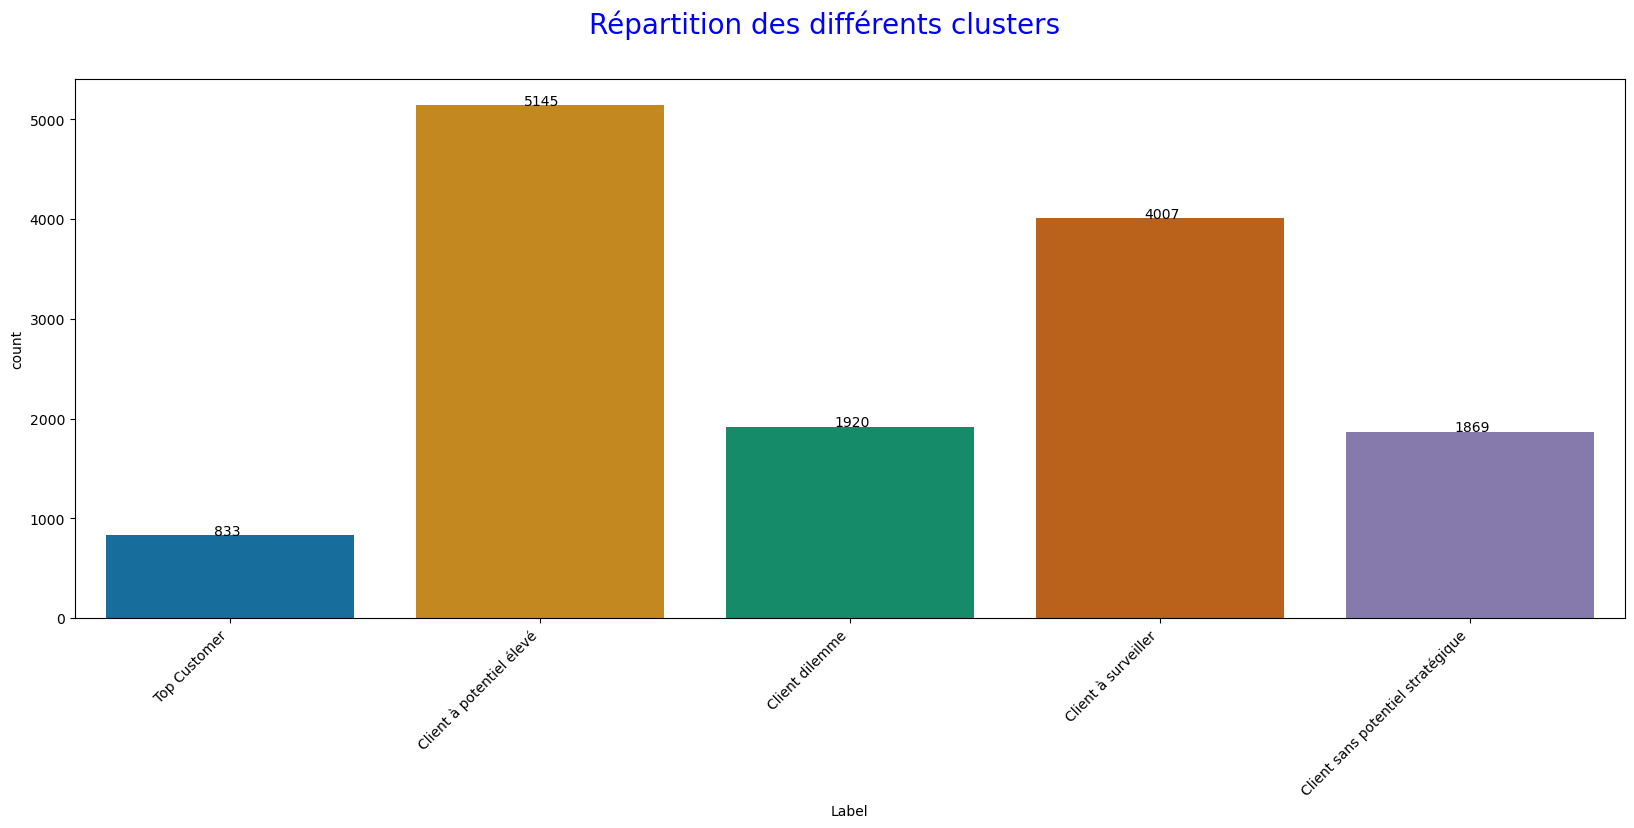

In [21]:
colors =['#0173b2', '#de8f05', '#029e73', '#d55e00', '#8172b3', '#ca9161', '#c44e52', '#949494', '#ece133', '#56b4e9']
fig = plt.figure(figsize=(20,7))
ax = fig.add_subplot()
sns.countplot(df_rfm2['Label'], palette=colors)
plt.xticks(rotation=45, horizontalalignment='right')
for p in ax.patches:
        ax.annotate('{}'.format(p.get_height()), (p.get_x() + 0.35, p.get_height() + 1));
    
plt.suptitle('Répartition des différents clusters', fontsize=20, color='b');

In [22]:
df_analysis = df_rfm2.groupby('Label').agg({'Label':'count'})

df_analysis.rename({'Label':'Total_customer_id'}, axis=1, inplace=True)
df_analysis['count_share'] = ((df_analysis['Total_customer_id'] / df_analysis['Total_customer_id'].sum()) * 100).round(2)

df_analysis.sort_values(by='Total_customer_id', ascending=False)

,Total_customer_id,count_share
Label,,
Client à potentiel élevé,5145,37.35
Client à surveiller,4007,29.09
Client dilemme,1920,13.94
Client sans potentiel stratégique,1869,13.57
Top Customer,833,6.05


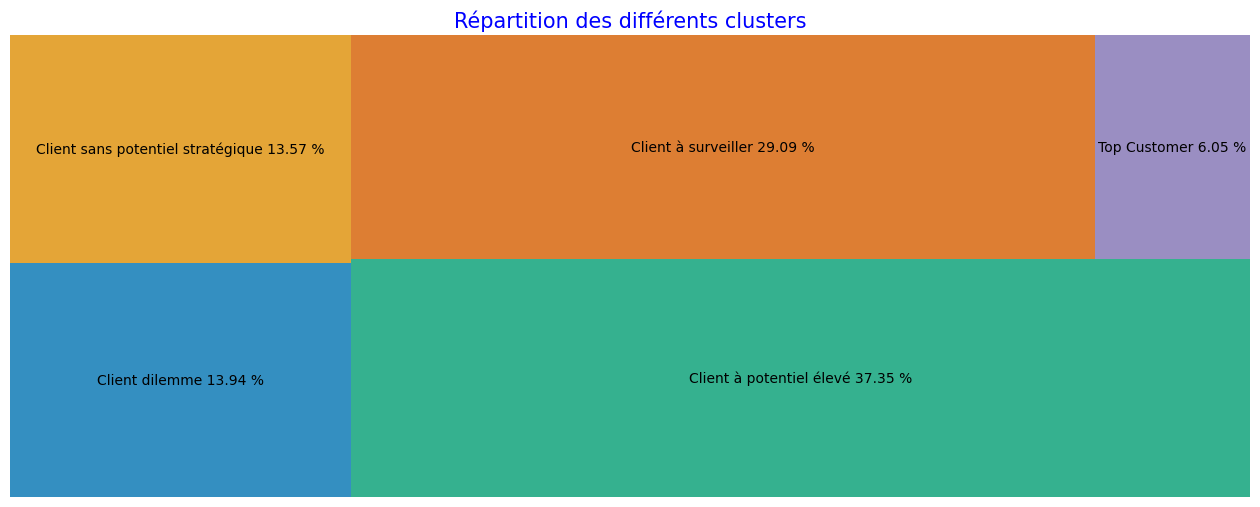

In [23]:
colors =['#0173b2', '#de8f05', '#029e73', '#d55e00', '#8172b3', '#ca9161', '#c44e52', '#949494', '#ece133', '#56b4e9']

labels = df_analysis.index + df_analysis['count_share'].apply(lambda x: ' ' + str(x) + ' %')

fig, ax = plt.subplots(figsize=(16,6))
squarify.plot(sizes=df_analysis['count_share'], label=labels, alpha=.8, color=colors)
ax.set_title('Répartition des différents clusters', fontsize=15, color='b')
plt.axis('off');


Nous choisissons la seconde approche pour les raisons suivantes:

- Définition simple et compréhensible des clusters, centrée sur le comportement client

- Souplesse et possibilité de faire évoluer simplement les modèles pour les mettre en phase avec la stratégie de développement de l'entreprise

- En l'absence d'experts, la première approche nous apparaît comme arbitraire, car le coefficient appliqué à chaque composante est subjectif

##### Création d'un nouveau dataframe "df2" regroupant les données de "df_rfm2" et de "df"

In [24]:
df2 = df_rfm2.merge(df, on = "Customer_id", how="left")

In [25]:
df_rfm2.sample()

,Customer_id,Recency,Frequency,Monetary,r_score,f_score,m_score,rfm,Label
2889,20004,633,4,11.72,1,2,3,123,Client à surveiller


In [26]:
df_rfm2['Label'].value_counts()

Client à potentiel élevé             5145
Client à surveiller                  4007
Client dilemme                       1920
Client sans potentiel stratégique    1869
Top Customer                          833
Name: Label, dtype: int64

In [27]:
df2 = df2.sort_values(by = "Increment_id", ascending=True)

In [28]:
df2.index = np.arange(df.shape[0])
df2.head(3)

,Customer_id,Recency,Frequency,Monetary,r_score,f_score,m_score,rfm,Label,Customer since,Item_id,Increment_id,Sales_commission_code,Qty_ordered,Price,Discount_amount,Net_income,Payment_method,Created_at,Year,Month,Category,Bi_status,Status,Regroupement_status,Regroupement_payment_method,Taux_change,Discount_amount_euros,Net_income_euros,Price_euros
0,4,1,392,20285.24,3,3,3,333,Top Customer,2016-07,211135,100147446,R-FSD-52352,1,360.0,300.0,60.0,cod,2016-07-01,2016,7,Beauty & Grooming,Net,complete,finalisé,cod,0.008686,2.61,0.52,3.13
1,11,560,6,40.03,2,2,3,223,Client à potentiel élevé,2016-07,211145,100147455,105259,1,120.0,0.0,120.0,ublcreditcard,2016-07-01,2016,7,Home & Living,Net,complete,finalisé,paiement immédiat,0.008686,0.00,1.04,1.04
2,11,560,6,40.03,2,2,3,223,Client à potentiel élevé,2016-07,211147,100147457,105259,1,1550.0,0.0,1550.0,ublcreditcard,2016-07-01,2016,7,Men's Fashion,Gross,canceled,annulé,paiement immédiat,0.008686,0.00,13.46,13.46


## <center>Analyse des différents clusters</center>

##### Cluster : Client à potentiel élevé

In [29]:
df_potentiel_eleve = df2[df2["Label"]=="Client à potentiel élevé"]
df_potentiel_eleve.head(2)

,Customer_id,Recency,Frequency,Monetary,r_score,f_score,m_score,rfm,Label,Customer since,Item_id,Increment_id,Sales_commission_code,Qty_ordered,Price,Discount_amount,Net_income,Payment_method,Created_at,Year,Month,Category,Bi_status,Status,Regroupement_status,Regroupement_payment_method,Taux_change,Discount_amount_euros,Net_income_euros,Price_euros
1,11,560,6,40.03,2,2,3,223,Client à potentiel élevé,2016-07,211145,100147455,105259,1,120.0,0.0,120.0,ublcreditcard,2016-07-01,2016,7,Home & Living,Net,complete,finalisé,paiement immédiat,0.008686,0.0,1.04,1.04
2,11,560,6,40.03,2,2,3,223,Client à potentiel élevé,2016-07,211147,100147457,105259,1,1550.0,0.0,1550.0,ublcreditcard,2016-07-01,2016,7,Men's Fashion,Gross,canceled,annulé,paiement immédiat,0.008686,0.0,13.46,13.46


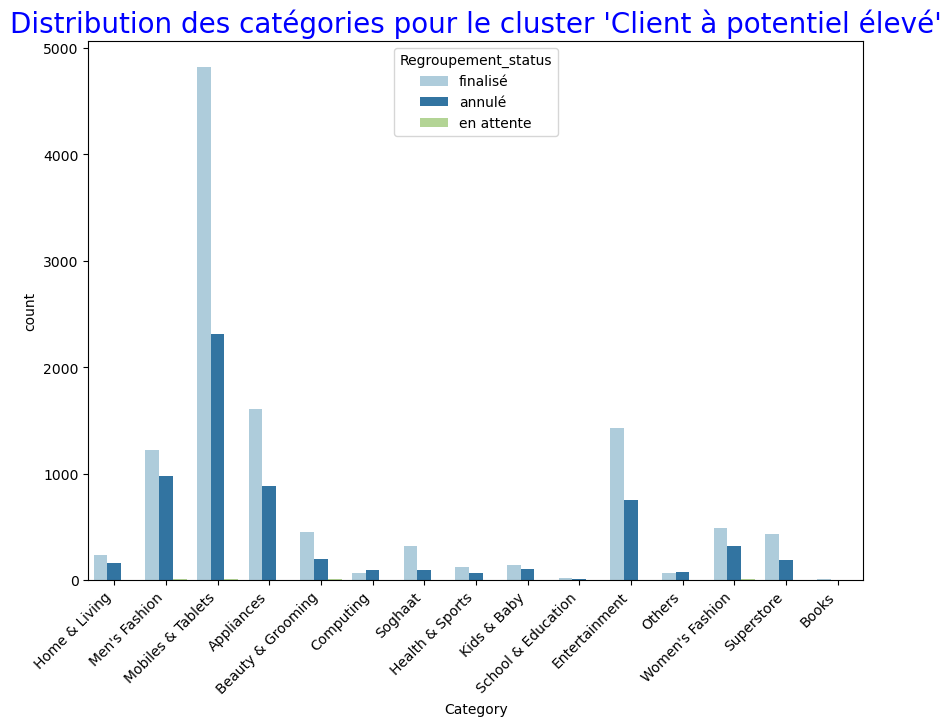

In [30]:
plt.figure(figsize=(10,7))
sns.countplot(df_potentiel_eleve["Category"], palette = "Paired", hue = df_potentiel_eleve["Regroupement_status"])
plt.xticks(rotation=45, horizontalalignment="right")
plt.title("Distribution des catégories pour le cluster 'Client à potentiel élevé'", fontsize=20, color="b");

In [31]:
# Création d'un dataframe 'df_discount_potentiel' regroupant les informations d'achats des 'Client à potentiel élevé'
# et le statut des commandes avec ou sans remise

df_discount_potentiel_status = pd.crosstab(df_potentiel_eleve['Category'], df_potentiel_eleve['Regroupement_status'])

df_discount_potentiel = pd.crosstab(df_potentiel_eleve['Category'], df_potentiel_eleve['Discount_amount'] ==0, normalize=0).round(2)
df_discount_potentiel.columns = ['Avec_remise', 'Sans_remise']
df_discount_potentiel['nb_commande'] = df_potentiel_eleve['Category'].value_counts()
df_discount_potentiel = df_discount_potentiel.merge(df_discount_potentiel_status, left_index=True, right_index=True)
df_discount_potentiel

,Avec_remise,Sans_remise,nb_commande,annulé,en attente,finalisé
Category,,,,,,
Appliances,0.81,0.19,2488,880,4,1604
Beauty & Grooming,0.21,0.79,647,193,7,447
Books,0.00,1.00,13,4,1,8
Computing,0.48,0.52,164,98,1,65
Entertainment,0.94,0.06,2183,755,2,1426
Health & Sports,0.38,0.62,190,64,3,123
Home & Living,0.23,0.77,397,159,4,234
Kids & Baby,0.18,0.82,239,100,1,138
Men's Fashion,0.13,0.87,2213,978,11,1224


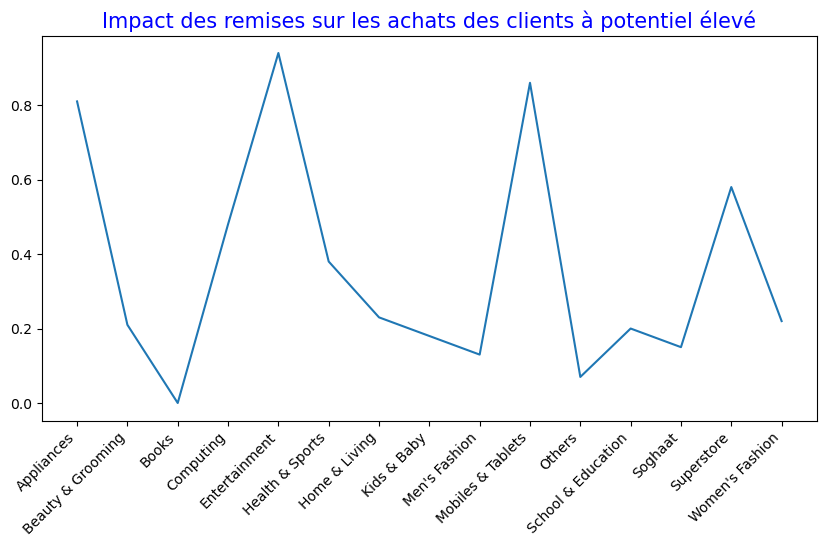

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(df_discount_potentiel.index, df_discount_potentiel['Avec_remise'])
plt.xticks(rotation=45, horizontalalignment='right')
plt.title('Impact des remises sur les achats des clients à potentiel élevé', fontsize=15, color='b');

Les clients à potentiel élevé achètent majoritairement des mobiles et tablettes et 86 % de ces achats bénéficient d'une promotion.

##### Cluster : Client dilemme

In [33]:
df_dilemme = df2[df2["Label"]=="Client dilemme"]
df_dilemme.head(2)

,Customer_id,Recency,Frequency,Monetary,r_score,f_score,m_score,rfm,Label,Customer since,Item_id,Increment_id,Sales_commission_code,Qty_ordered,Price,Discount_amount,Net_income,Payment_method,Created_at,Year,Month,Category,Bi_status,Status,Regroupement_status,Regroupement_payment_method,Taux_change,Discount_amount_euros,Net_income_euros,Price_euros
3,13,595,192,5220.82,2,3,3,233,Client dilemme,2016-07,211149,100147458,R-KHW-104406,1,420.0,0.0,1270.0,cod,2016-07-01,2016,7,Soghaat,Net,complete,finalisé,cod,0.008686,0.0,11.03,3.65
4,13,595,192,5220.82,2,3,3,233,Client dilemme,2016-07,211150,100147458,R-KHW-104406,1,360.0,0.0,1270.0,cod,2016-07-01,2016,7,Soghaat,Net,complete,finalisé,cod,0.008686,0.0,11.03,3.13


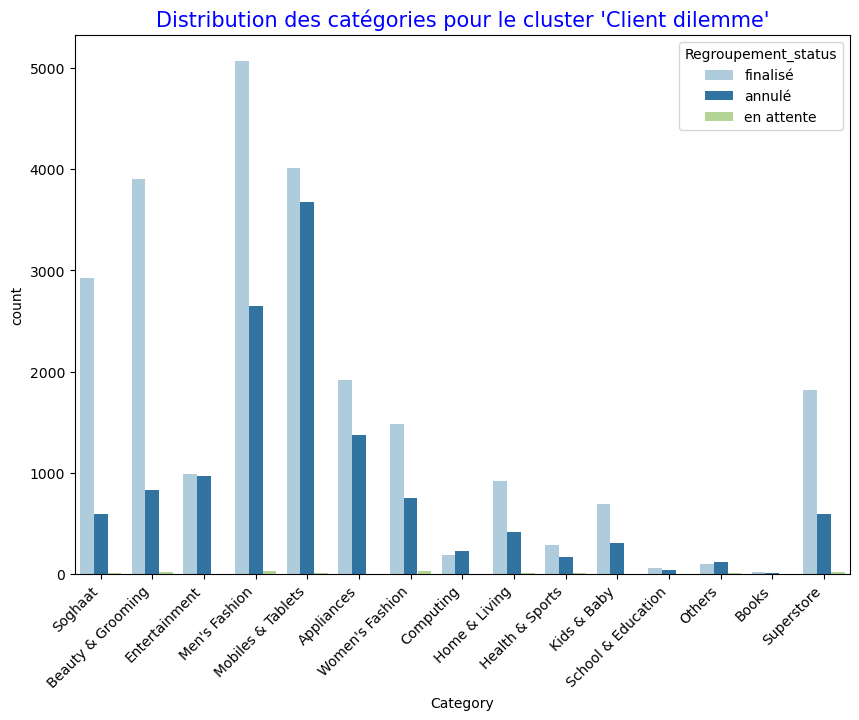

In [34]:
plt.figure(figsize=(10,7))
sns.countplot(df_dilemme["Category"], palette = "Paired", hue = df_dilemme["Regroupement_status"])
plt.xticks(rotation=45, horizontalalignment="right")
plt.title("Distribution des catégories pour le cluster 'Client dilemme'", fontsize=15, color="b");

In [35]:
pd.crosstab(df_dilemme['Category'], df_dilemme['Regroupement_status'] != "annulé", normalize=0).round(2)

Regroupement_status,False,True
Category,,
Appliances,0.42,0.58
Beauty & Grooming,0.17,0.83
Books,0.36,0.64
Computing,0.54,0.46
Entertainment,0.50,0.50
Health & Sports,0.36,0.64
Home & Living,0.31,0.69
Kids & Baby,0.31,0.69
Men's Fashion,0.34,0.66


Le constat liminaire est que ce type de client est caractérisé par un fort taux d'annulation des commandes effectuées. 

In [36]:
# Création d'un dataframe 'df_discount_dilemme' regroupant les informations d'achats des 'client dilemme'
# et le statut des commandes avec ou sans remise

df_discount_dilemme_status = pd.crosstab(df_dilemme['Category'], df_dilemme['Regroupement_status'])

df_discount_dilemme = pd.crosstab(df_dilemme['Category'], df_dilemme['Discount_amount_euros'] ==0, normalize=0).round(2)
df_discount_dilemme.columns = ['Avec_remise', 'Sans_remise']
df_discount_dilemme['nb_commande'] = df_dilemme['Category'].value_counts()
df_discount_dilemme = df_discount_dilemme.merge(df_discount_dilemme_status, left_index=True, right_index=True)
df_discount_dilemme

,Avec_remise,Sans_remise,nb_commande,annulé,en attente,finalisé
Category,,,,,,
Appliances,0.53,0.47,3288,1373,1,1914
Beauty & Grooming,0.13,0.87,4750,829,21,3900
Books,0.00,1.00,25,9,1,15
Computing,0.36,0.64,416,226,3,187
Entertainment,0.76,0.24,1951,966,1,984
Health & Sports,0.11,0.89,456,165,7,284
Home & Living,0.25,0.75,1345,417,11,917
Kids & Baby,0.13,0.87,999,306,4,689
Men's Fashion,0.07,0.93,7751,2645,34,5072


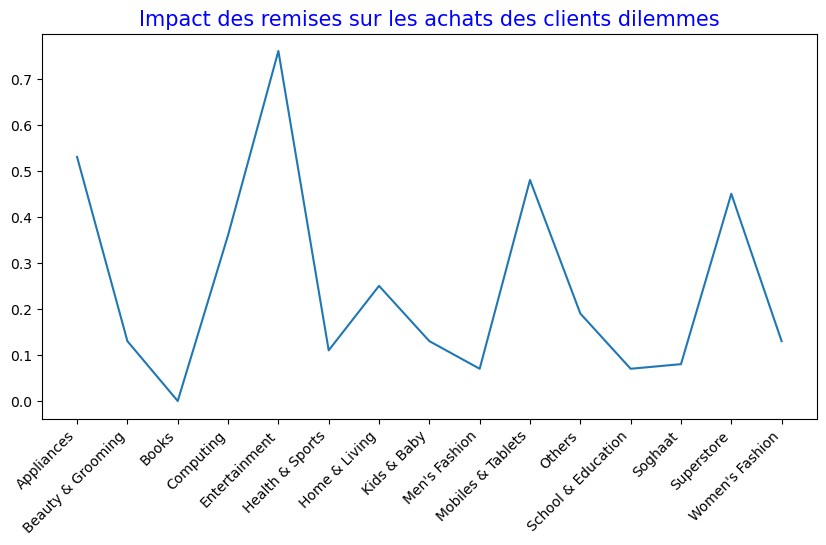

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(df_discount_dilemme.index, df_discount_dilemme['Avec_remise'])
plt.xticks(rotation=45, horizontalalignment='right')
plt.title('Impact des remises sur les achats des clients dilemmes', fontsize=15, color='b');

Nous constatons que sur les catégories telles que 'Entertainment' et 'Mobiles & Tablets', les promotions ont une influence conséquente sur les volumes de vente (jusqu'à 70%).

A l'inverse, dans la catégorie 'Men's Fashion', qui totalise le volume de vente le plus important, les clients dilemmes ne sont pas sensibles aux promotions.

##### Comparaison de l'influence des promotions sur les achats des profils "Client dilemme" et "Client à potentiel élevé"

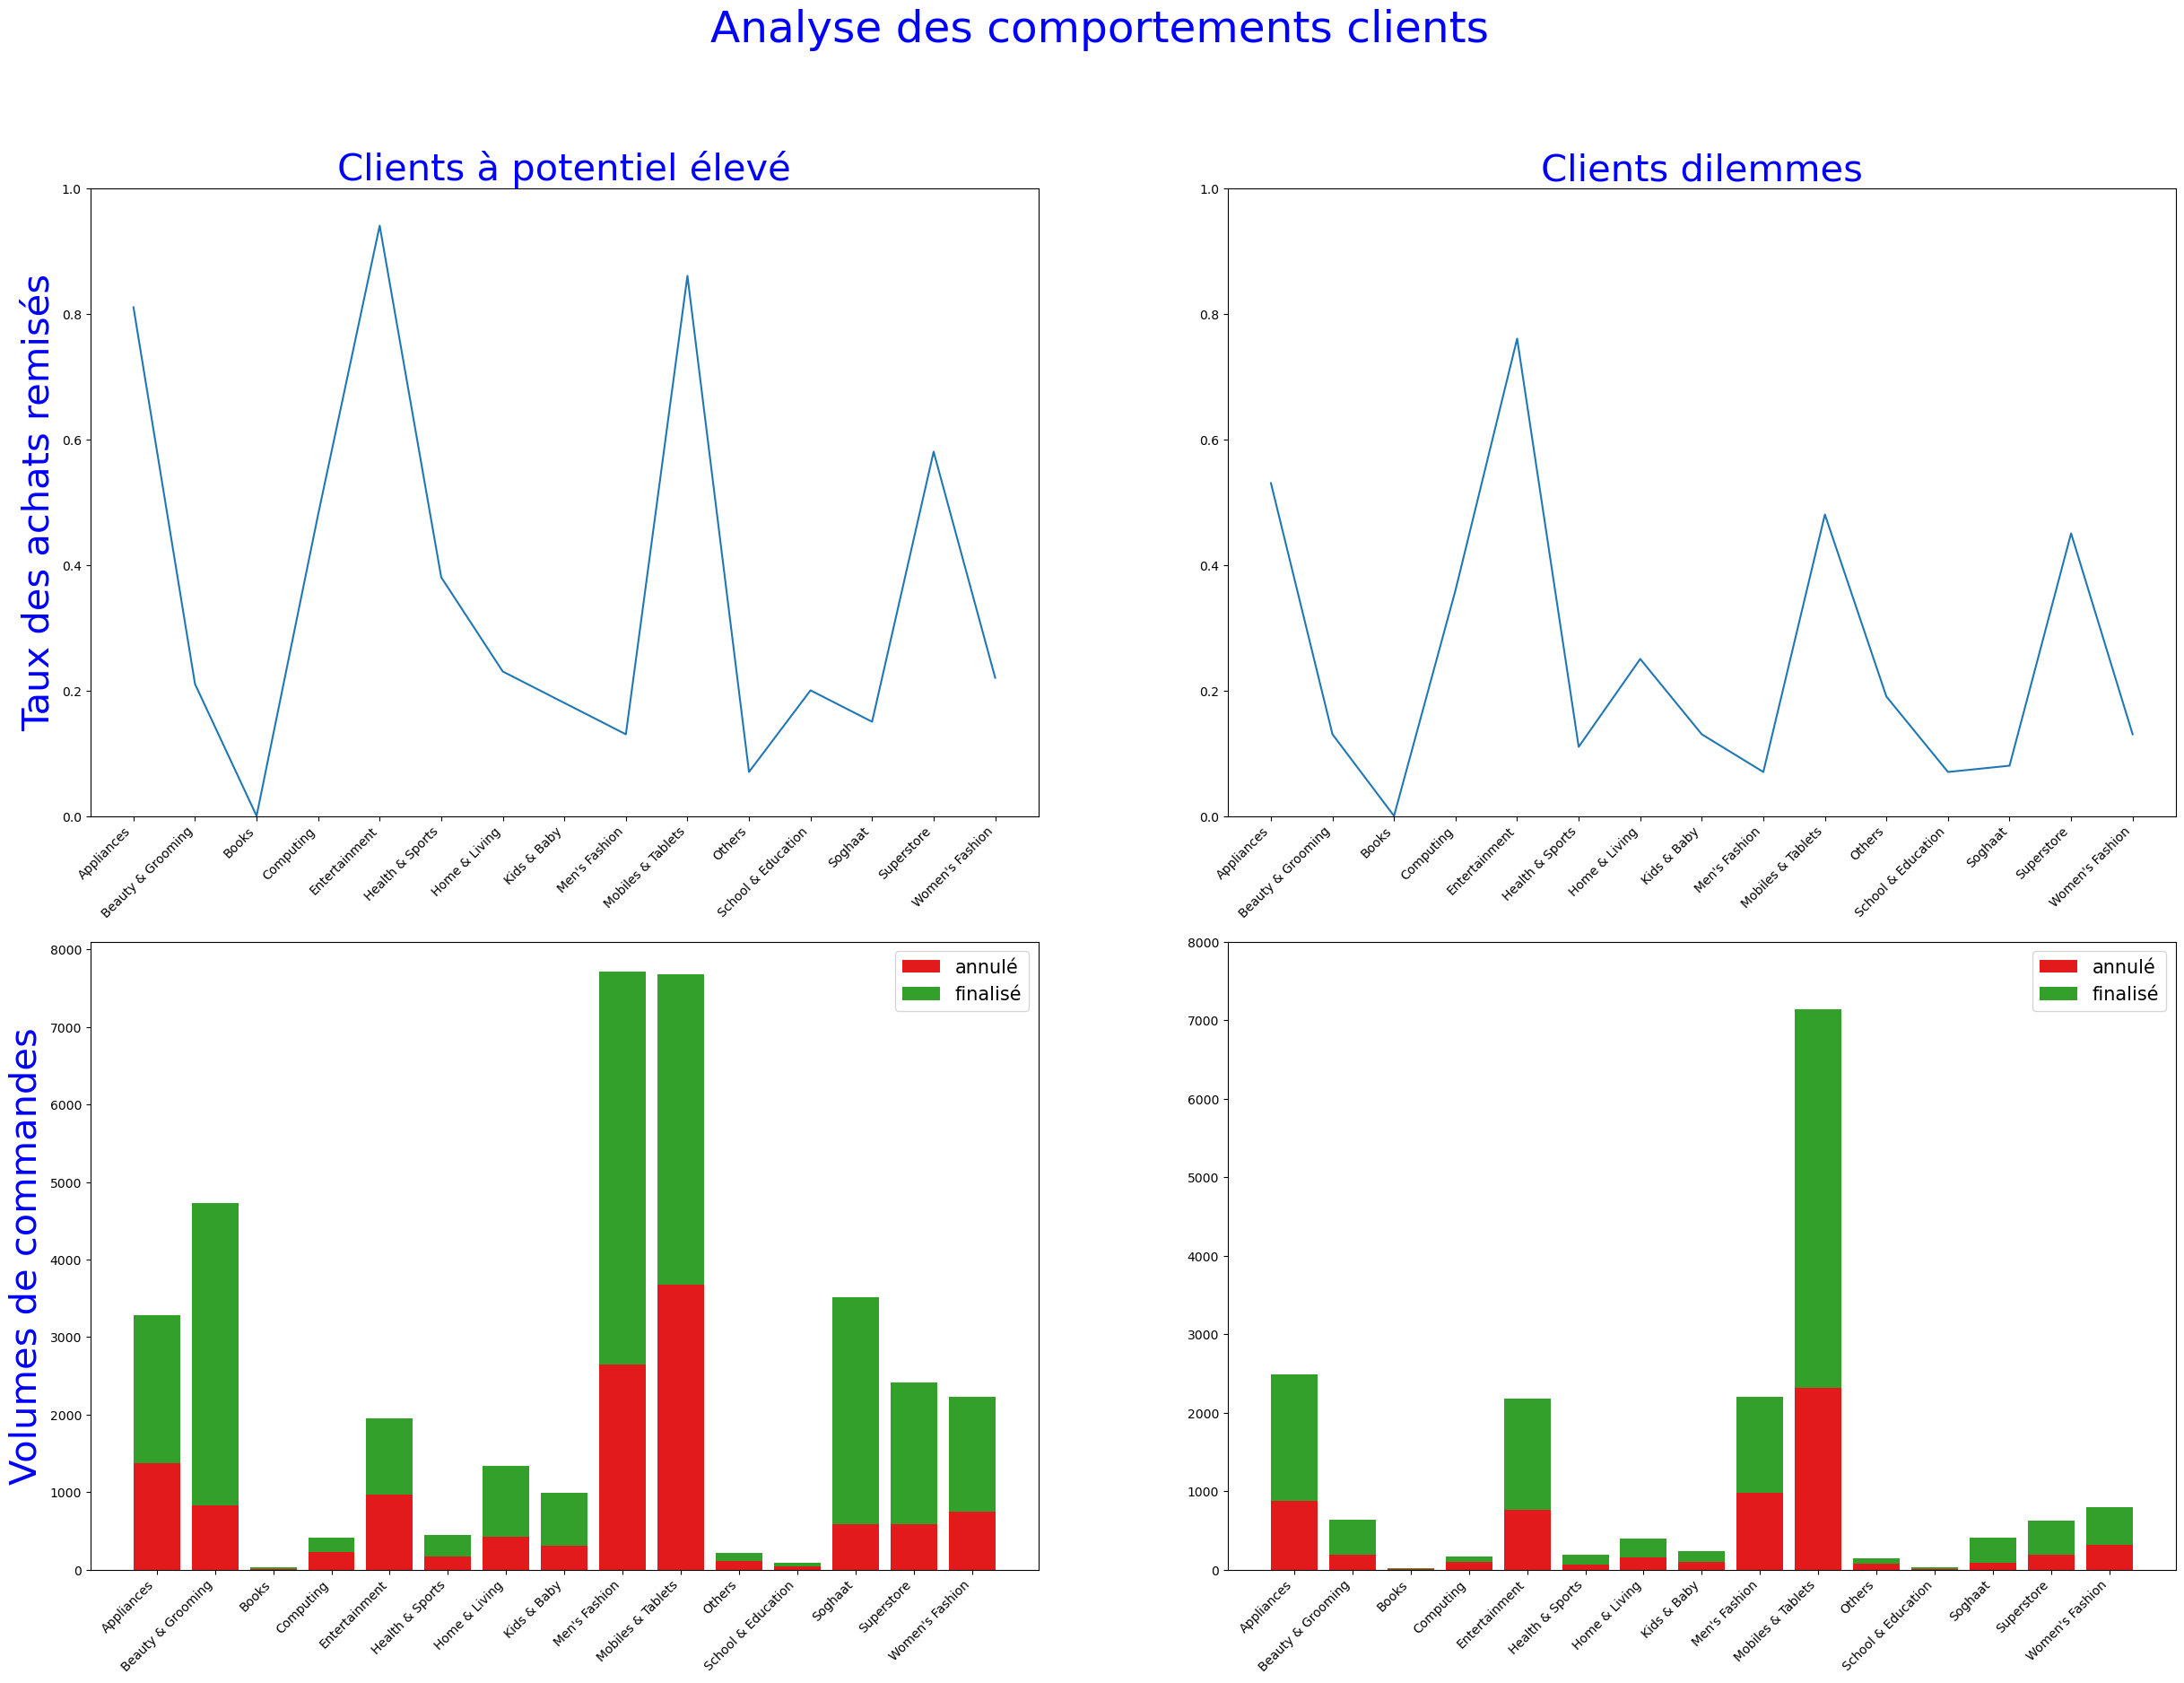

In [38]:
plt.figure(figsize=(30, 20))
plt.subplot(221)
plt.plot(df_discount_potentiel.index, df_discount_potentiel['Avec_remise'])
plt.xticks(rotation=45, horizontalalignment='right')
plt.ylim(0,1)
plt.ylabel('Taux des achats remisés', color='b', fontsize=30)
plt.title('Clients à potentiel élevé', fontsize=30, color='b')
plt.subplot(222)
plt.plot(df_discount_dilemme.index, df_discount_dilemme['Avec_remise'])
plt.xticks(rotation=45, horizontalalignment='right')
plt.ylim(0,1)
plt.title('Clients dilemmes', fontsize=30, color='b')
plt.suptitle('Analyse des comportements clients', fontsize=35, color='b');
plt.subplot(223)
plt.bar(df_discount_dilemme.index, df_discount_dilemme['annulé'], label='annulé', color='#e31a1c')
plt.bar(df_discount_dilemme.index, df_discount_dilemme['finalisé'], bottom=df_discount_dilemme['annulé'],
                                                label='finalisé', color='#33a02c')
plt.xticks(rotation=45, horizontalalignment='right')
plt.ylabel('Volumes de commandes', color='b', fontsize=30)
plt.legend(fontsize=15)
plt.subplot(224)
plt.bar(df_discount_potentiel.index, df_discount_potentiel['annulé'], label='annulé', color='#e31a1c')
plt.bar(df_discount_potentiel.index, df_discount_potentiel['finalisé'], bottom=df_discount_potentiel['annulé'],
        label='finalisé', color='#33a02c')
plt.xticks(rotation=45, horizontalalignment='right')
plt.ylim(0,8000)
plt.legend(fontsize=15);

##### Recommandations pour les clients dilemmes 
Leur volume d'achat est déjà important. L'enjeu est donc de maximiser le nombre de commandes sur ce cluster.
Il faudrait augmenter le nombre des clients dilemmes, et essayer de les fidéliser en communiquant sur les articles à succès (notifications push, utilisations des cookies, ...). Le but n'est pas de changer profondément leurs habitudes de consommation.


Exception faite des mobiles et tablettes, ils sont peu sensibles aux promotions. Cependant on constate que leurs achats sont axés sur les articles de mode, de beauté, ainsi que des mobiles et tablettes.


Nous proposons pour ce cluster d'orienter les publicités sur ces catégories de produits afin d'accroître le nombre de ventes.

##### Recommandations pour les clients à potentiels élevés


On constate que le volume des ventes des clients à potentiel élevés est moins important que celui des clients dilemmes.

On remarque aussi qu'ils sont sensibles aux promotions.

Le but serait d'augmenter leurs consommations, afin de les faire intégrer le cluster 'Top Customer'.

Afin de stimuler les achats de ces clients, une piste serait de leur proposer des opérations promotionnelles exclusives et ciblées (ventes privées, pré soldes, ...). 

##### Cluster : Client à surveiller

In [39]:
df_comparaison = df2.loc[(df2['Label']=='Client à surveiller') | (df2['Label']=='Top Customer')]

df_comparaison2 = pd.crosstab(df_comparaison['Category'], df_comparaison['Label'])
df_comparaison2

Label,Client à surveiller,Top Customer
Category,,
Appliances,951,4793
Beauty & Grooming,1421,3003
Books,11,8
Computing,211,395
Entertainment,576,3343
Health & Sports,130,732
Home & Living,279,1098
Kids & Baby,303,832
Men's Fashion,2634,5806


In [40]:
df_comparaison2 = df_comparaison2.reindex(df_comparaison['Category'].unique())

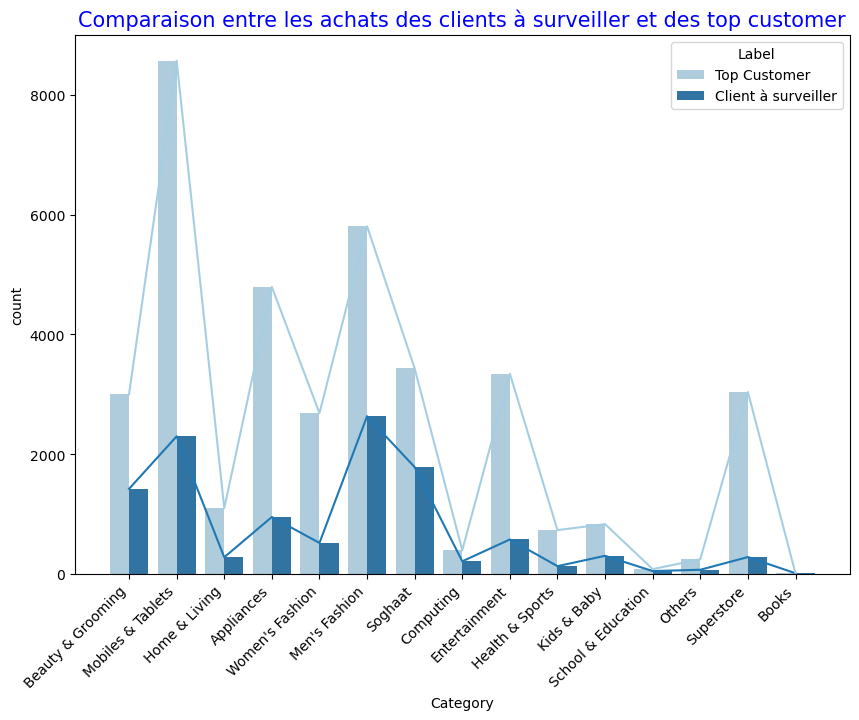

In [41]:
plt.figure(figsize=(10,7))
sns.countplot(df_comparaison["Category"], palette = "Paired", hue = df_comparaison["Label"])
plt.plot(df_comparaison['Category'].unique(), df_comparaison2['Client à surveiller'], c='#1f78b4')
plt.plot(df_comparaison['Category'].unique(), df_comparaison2['Top Customer'], c='#a6cee3')
plt.xticks(rotation=45, horizontalalignment="right")
plt.title("Comparaison entre les achats des clients à surveiller et des top customer", fontsize=15, color="b");

Nous avons des profils d'achats comparables, ce qui confirme que les clients à surveiller sont d'anciens clients 'Top Customer'.

Nous allons étudier par la suite différentes pistes afin de trouver un moyen de relancer leur consommation.

###### Impact des remises sur les clients à surveiller

In [42]:
df_a_surveiller = df2[df2["Label"]=="Client à surveiller"]

In [43]:
# Création d'un dataframe 'df_discount_a_surveiller' regroupant les informations d'achats des 'client à surveiller'
# et le statut des commandes avec ou sans remise

df_discount_a_surveiller_status = pd.crosstab(df_a_surveiller['Category'], df_a_surveiller['Regroupement_status'])

df_discount_a_surveiller = pd.crosstab(df_a_surveiller['Category'], df_a_surveiller['Discount_amount_euros'] ==0, normalize=0).round(2)
df_discount_a_surveiller.columns = ['Avec_remise', 'Sans_remise']
df_discount_a_surveiller['nb_commande'] = df_a_surveiller['Category'].value_counts()
df_discount_a_surveiller = df_discount_a_surveiller.merge(df_discount_a_surveiller_status, left_index=True, right_index=True)
df_discount_a_surveiller


,Avec_remise,Sans_remise,nb_commande,annulé,finalisé
Category,,,,,
Appliances,0.45,0.55,951,456,495
Beauty & Grooming,0.12,0.88,1421,353,1068
Books,0.00,1.00,11,4,7
Computing,0.45,0.55,211,119,92
Entertainment,0.57,0.43,576,326,250
Health & Sports,0.08,0.92,130,48,82
Home & Living,0.23,0.77,279,107,172
Kids & Baby,0.02,0.98,303,90,213
Men's Fashion,0.05,0.95,2634,1025,1609


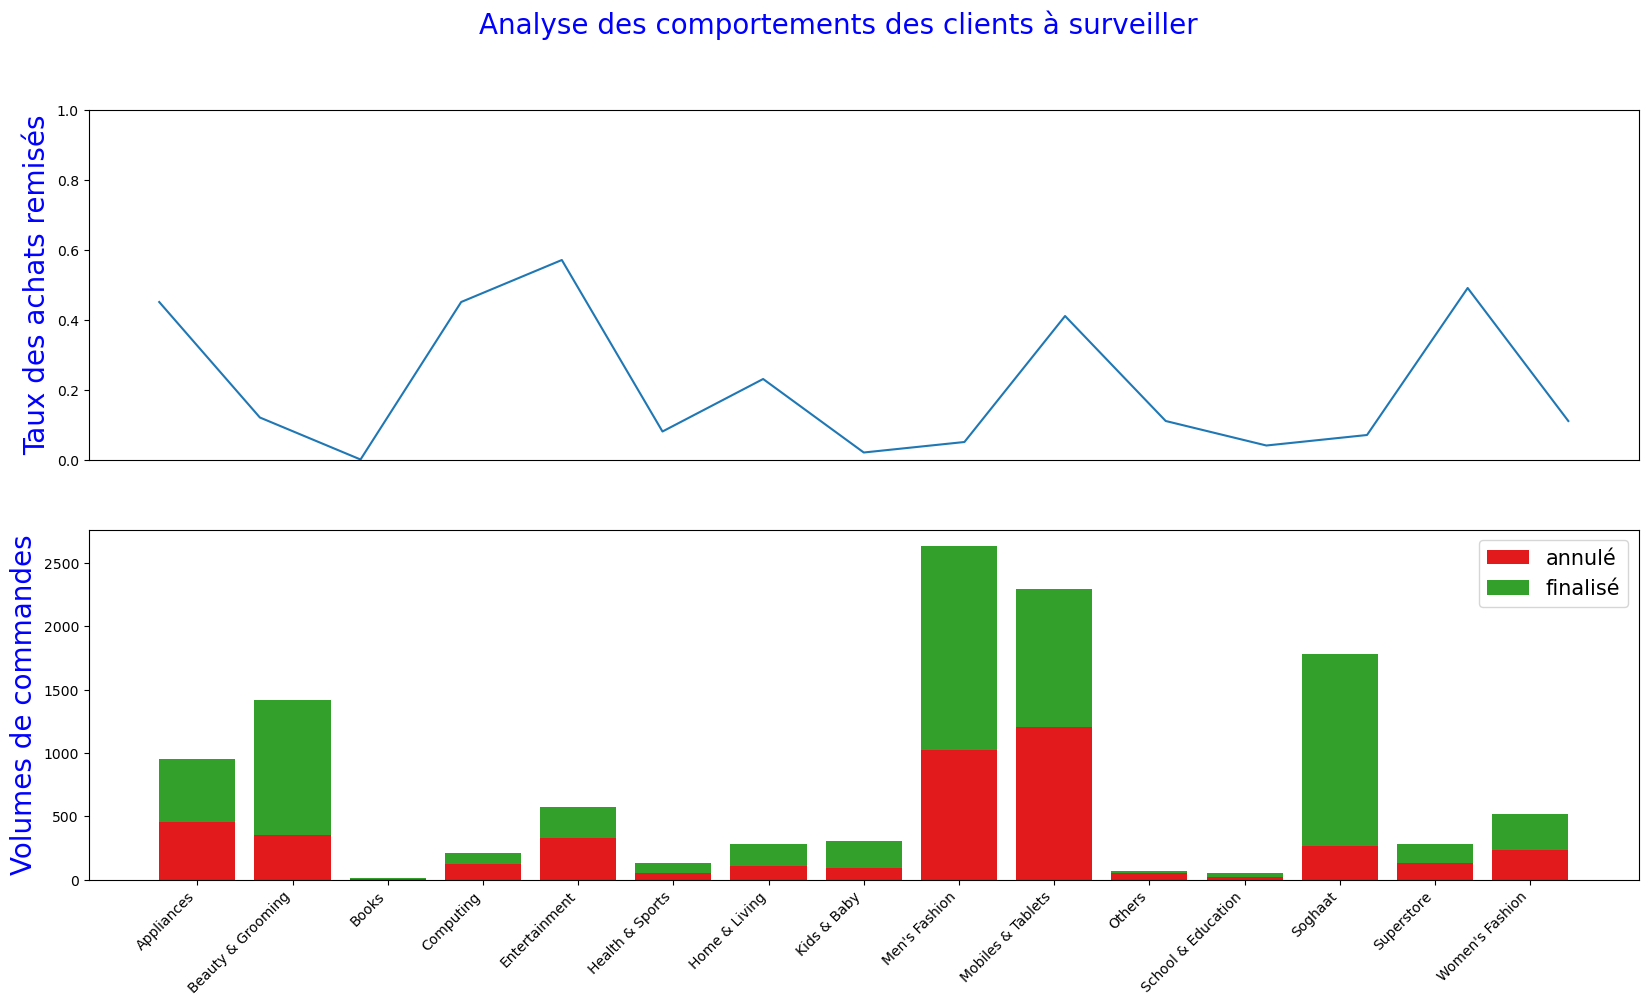

In [44]:
plt.figure(figsize=(20,10))
plt.subplot(211)
plt.plot(df_discount_a_surveiller.index, df_discount_a_surveiller['Avec_remise'])
plt.xticks(rotation=45, horizontalalignment='right')
plt.ylim(0,1)
plt.ylabel('Taux des achats remisés', color='b', fontsize=20)
plt.xticks(' ')
plt.subplot(212)
plt.bar(df_discount_a_surveiller.index, df_discount_a_surveiller['annulé'], label='annulé', color='#e31a1c')
plt.bar(df_discount_a_surveiller.index, df_discount_a_surveiller['finalisé'], bottom=df_discount_a_surveiller['annulé'],
                                                label='finalisé', color='#33a02c')
plt.xticks(rotation=45, horizontalalignment='right')
plt.ylabel('Volumes de commandes', color='b', fontsize=20)
plt.legend(fontsize=15)
plt.suptitle('Analyse des comportements des clients à surveiller', fontsize=20, color='b');

##### Recommandations pour les clients à surveiller

Concernant les 'Mobiles & Tablets', qui représentent l'un des plus gros volumes de vente, on observe d'une part une proportion élevée d'annulations, et d'autre part une prépondérance des achats remisés (environ 40% du total des commandes). On peut se demander si les remises influencent la finalisation des achats.

En ce qui concerne les autres catégories, les remises ne déclenchent pas d'achat, il faudrait trouver d'autres solutions pour dynamiser les ventes, par exemple communiquer sur les produits d'appel ("Men's Fashion", "Soghaat", ...) 